In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

plt.rcParams['figure.figsize'] = (10,6)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [4]:
print("Historical Trades Dataset")
display(trades.head())

print("Fear & Greed Dataset")
display(sentiment.head())

Historical Trades Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [11]:

sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [13]:
print("Trades Missing Values")
print(trades.isnull().sum())

print(" ")
print("Sentiment Missing Values")
print(sentiment.isnull().sum())

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
 
Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [15]:
print(trades.columns)
print(" ")
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
 
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [17]:
print("Duplicate rows in trades:", trades.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())

#deleting duplicates if exists

trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

Duplicate rows in trades: 0
Duplicate rows in sentiment: 0


In [19]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date
trades['Timestamp'].head()

,Timestamp
0,1.730000e+12
1,1.730000e+12
2,1.730000e+12
3,1.730000e+12
4,1.730000e+12


In [21]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['Date'] = trades['Timestamp'].dt.date
trades[['Timestamp', 'Date']].head()

,Timestamp,Date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


In [22]:
print("Trades:")
print(trades['Date'].min())
print(trades['Date'].max())

print()

print("Sentiment:")
print(sentiment['Date'].min())
print(sentiment['Date'].max())

Trades:
2023-03-28
2025-06-15

Sentiment:
2018-02-01
2025-05-02


In [23]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'Fee'
]

print(trades[numeric_cols].describe())


       Execution Price   Size Tokens      Size USD     Closed PnL  \
count    211224.000000  2.112240e+05  2.112240e+05  211224.000000   
mean      11414.723350  4.623365e+03  5.639451e+03      48.749001   
std       29447.654868  1.042729e+05  3.657514e+04     919.164828   
min           0.000005  8.740000e-07  0.000000e+00 -117990.104100   
25%           4.854700  2.940000e+00  1.937900e+02       0.000000   
50%          18.280000  3.200000e+01  5.970450e+02       0.000000   
75%         101.580000  1.879025e+02  2.058960e+03       5.792797   
max      109004.000000  1.582244e+07  3.921431e+06  135329.090100   

                 Fee  
count  211224.000000  
mean        1.163967  
std         6.758854  
min        -1.175712  
25%         0.016121  
50%         0.089578  
75%         0.393811  
max       837.471593  


In [29]:
# Keep only the required columns from the sentiment dataset
sentiment_df = sentiment[['Date', 'classification', 'value']]

# Merge
df = pd.merge(
    trades,
    sentiment_df,
    on='Date',
    how='left'
)


df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed,74.0


In [30]:
print(df.shape)

(211224, 19)


In [31]:
df[['classification', 'value']].isnull().sum()

,0
classification,26961
value,26961


In [32]:
df = df.dropna(subset=['classification'])

In [33]:
print(df.shape)

(184263, 19)


In [34]:
df['classification'].value_counts()
print("Unique Traders:", df['Account'].nunique())

print(df['Coin'].value_counts())

print(df['Closed PnL'].describe())
print("Total PnL:", df['Closed PnL'].sum())


Unique Traders: 32
Coin
HYPE    62446
@107    27385
BTC     20135
ETH     10862
SOL      8523
        ...  
@42         1
@135        1
@18         1
@68         1
@86         1
Name: count, Length: 239, dtype: int64
count    184263.000000
mean         55.492690
std         937.857954
min     -117990.104100
25%           0.000000
50%           0.000000
75%           6.602400
max      135329.090100
Name: Closed PnL, dtype: float64
Total PnL: 10225249.595801996


In [ ]:
#performance of trader

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


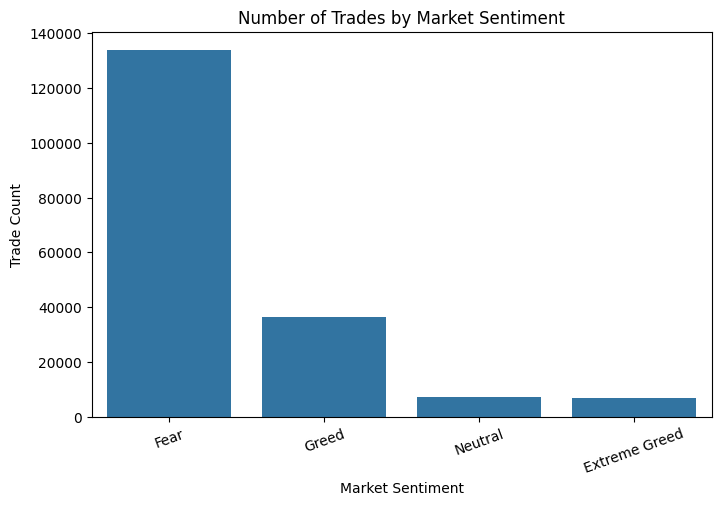

In [35]:
trade_count = df['classification'].value_counts()

print(trade_count)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='classification', order=trade_count.index)
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=20)
plt.show()

classification
Greed            87.894859
Fear             50.047622
Extreme Greed    25.418772
Neutral          22.229713
Name: Closed PnL, dtype: float64


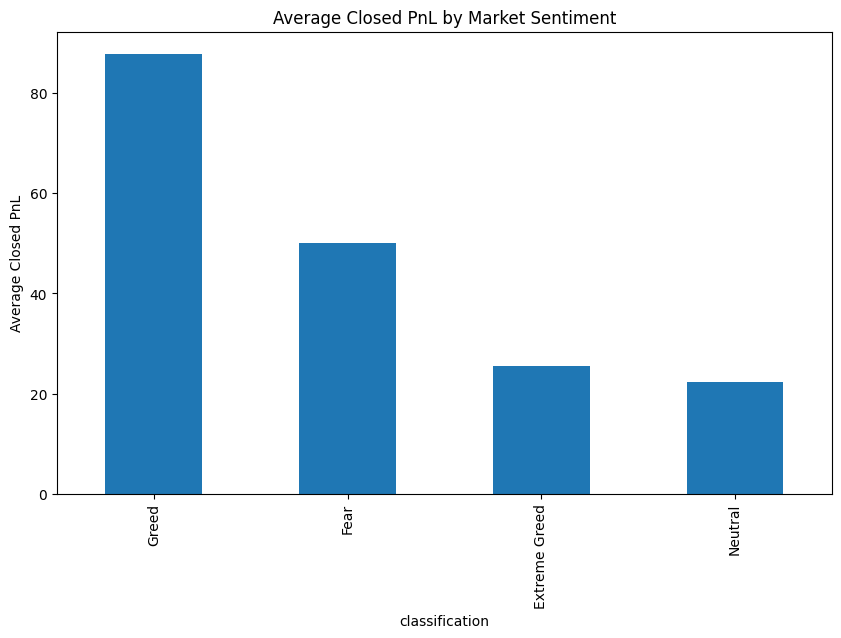

In [36]:
avg_pnl = df.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

print(avg_pnl)

avg_pnl.plot(kind='bar')
plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

classification
Fear             6.699925e+06
Greed            3.189617e+06
Extreme Greed    1.769655e+05
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64


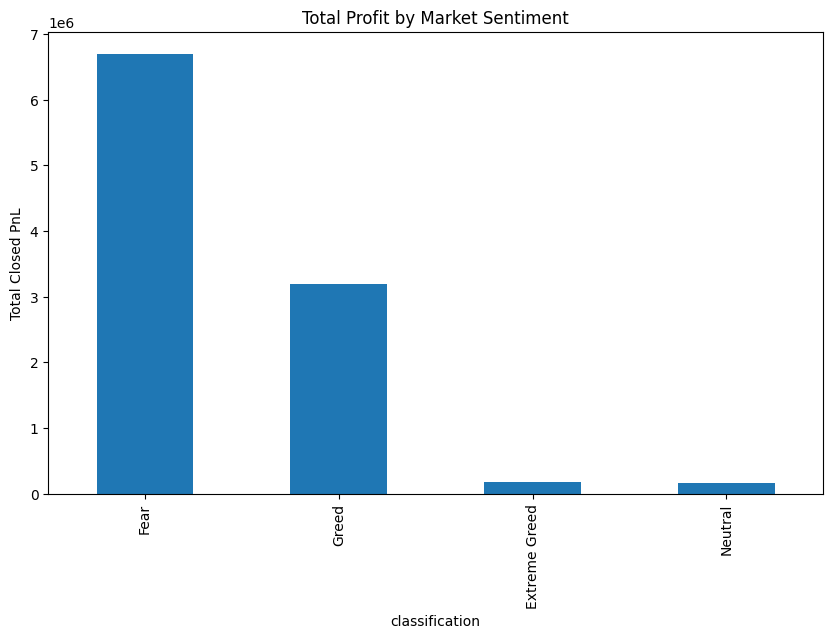

In [38]:
total_pnl = df.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

print(total_pnl)

total_pnl.plot(kind='bar')
plt.title("Total Profit by Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.show()

classification
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: Closed PnL, dtype: float64


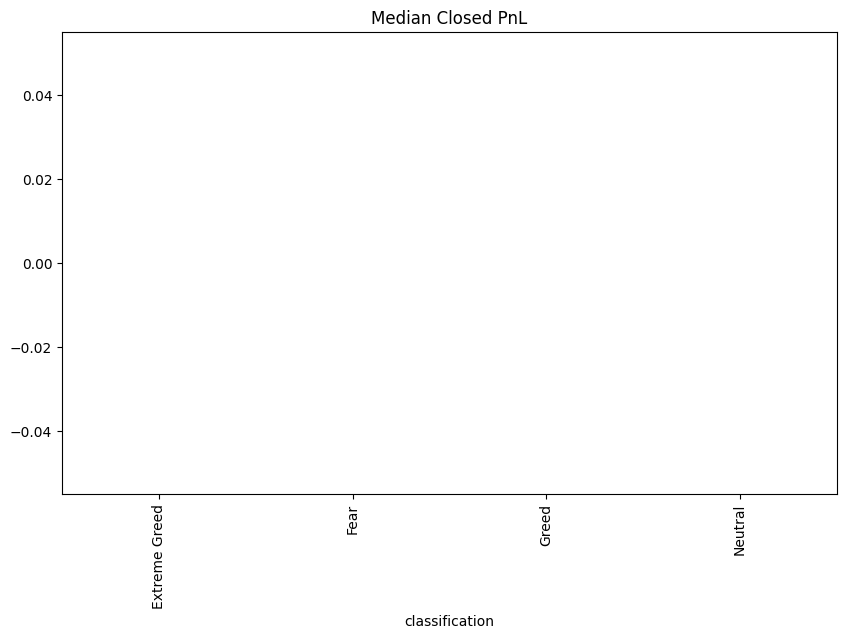

In [39]:
median_pnl = df.groupby('classification')['Closed PnL'].median()

print(median_pnl)

median_pnl.plot(kind='bar')
plt.title("Median Closed PnL")
plt.show()

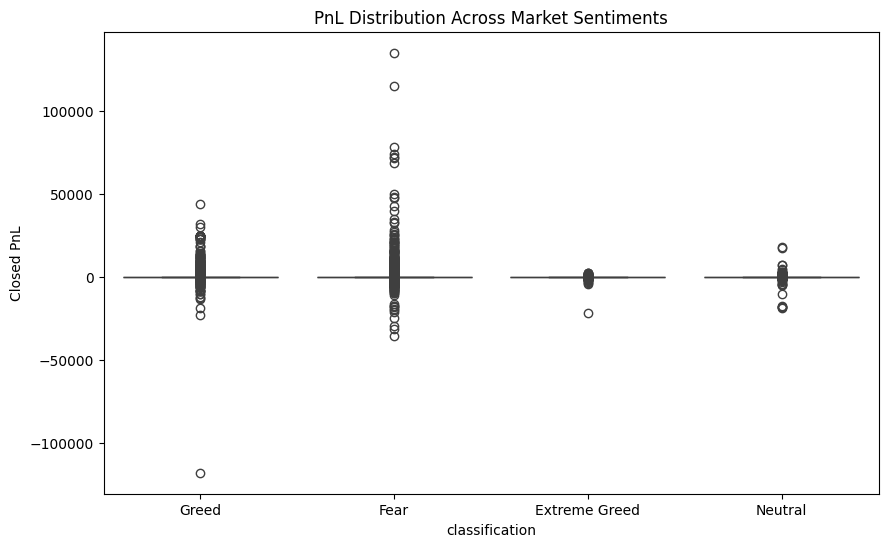

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution Across Market Sentiments")
plt.show()

classification
Extreme Greed    3.940677e+07
Fear             7.041585e+08
Greed            1.155037e+08
Neutral          2.184323e+07
Name: Size USD, dtype: float64


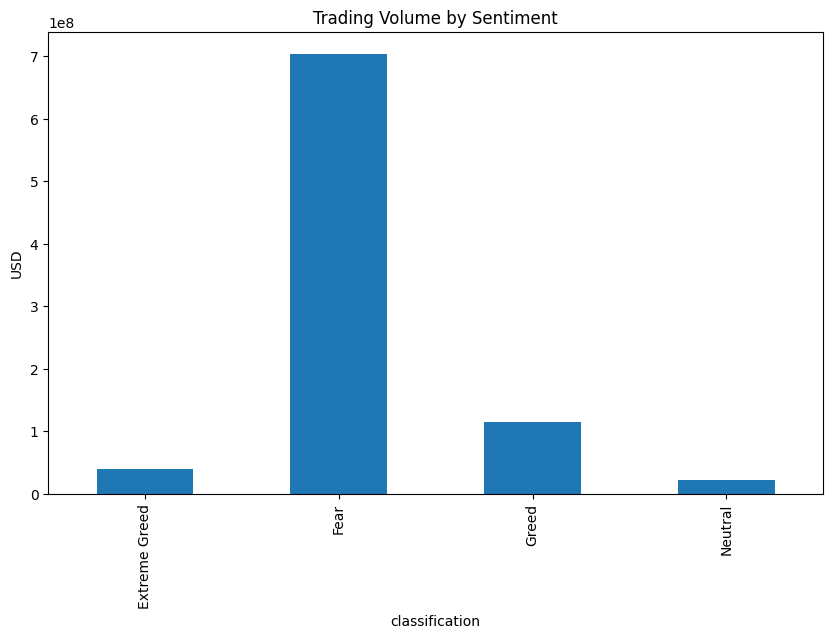

In [41]:
volume = df.groupby('classification')['Size USD'].sum()

print(volume)

volume.plot(kind='bar')
plt.title("Trading Volume by Sentiment")
plt.ylabel("USD")
plt.show()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


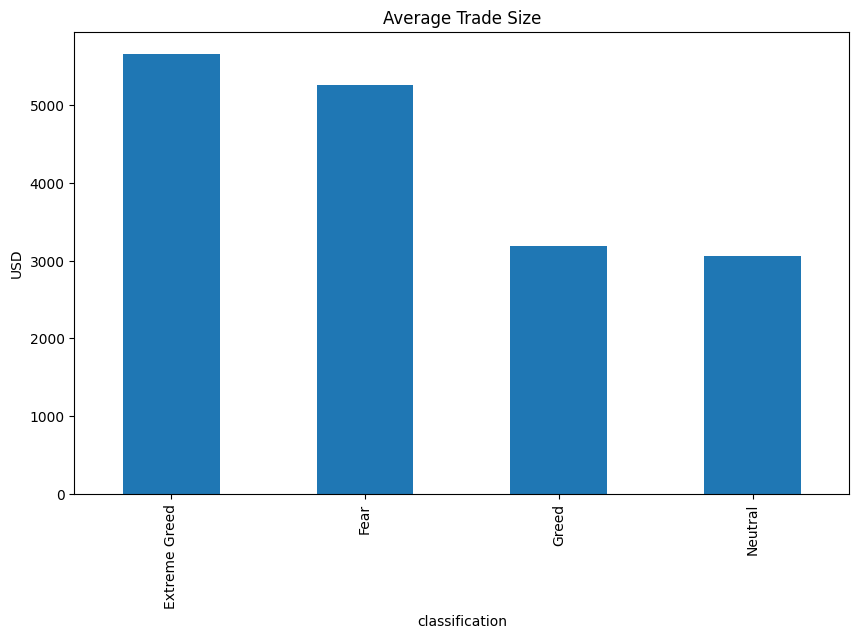

In [46]:
avg_size = df.groupby('classification')['Size USD'].mean()

print(avg_size)

avg_size.plot(kind='bar')
plt.title("Average Trade Size")
plt.ylabel("USD")
plt.show()



In [48]:
pd.crosstab(
    df['classification'],
    df['Side']
)

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


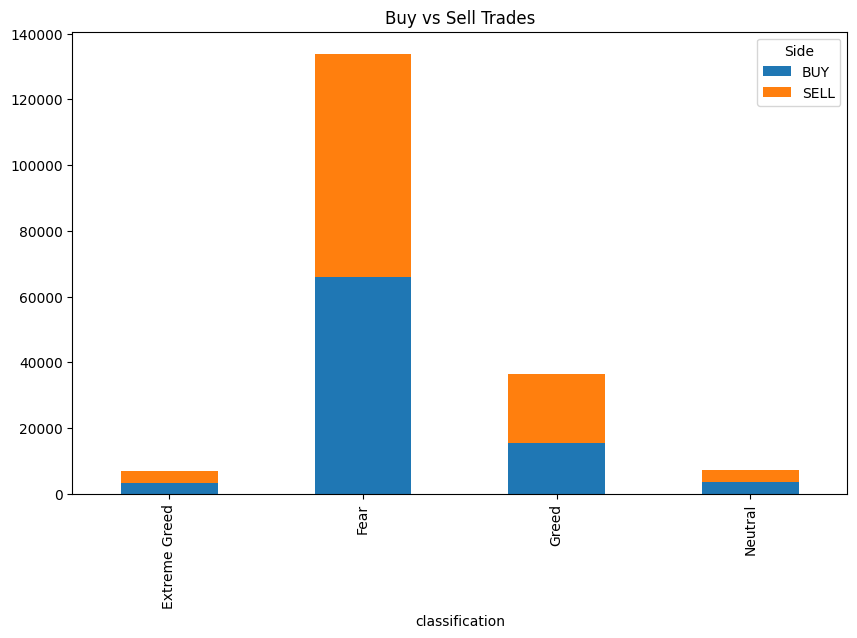

In [50]:


pd.crosstab(
    df['classification'],
    df['Side']
).plot(kind='bar', stacked=True)

plt.title("Buy vs Sell Trades")
plt.savefig("buy_vs_sell_traders", dpi=300, bbox_inches='tight')
plt.show()

In [49]:
buy_sell = df.groupby(
    ['classification','Side']
)['Closed PnL'].mean()

print(buy_sell)

classification  Side
Extreme Greed   BUY      25.578564
                SELL     25.268770
Fear            BUY      58.074630
                SELL     42.222976
Greed           BUY      12.489506
                SELL    143.617782
Neutral         BUY      15.646108
                SELL     28.576120
Name: Closed PnL, dtype: float64


In [55]:
top_traders = (
    df.groupby('Account')['Closed PnL']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.040922e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401572e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.111830e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.744040e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.258152e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.936830e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.615766e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    3.371137e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.012879e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x8170715b3b381dffb7062c0298972d4727a0a63b    1.963038e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686280e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.323155e+05
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d    1.

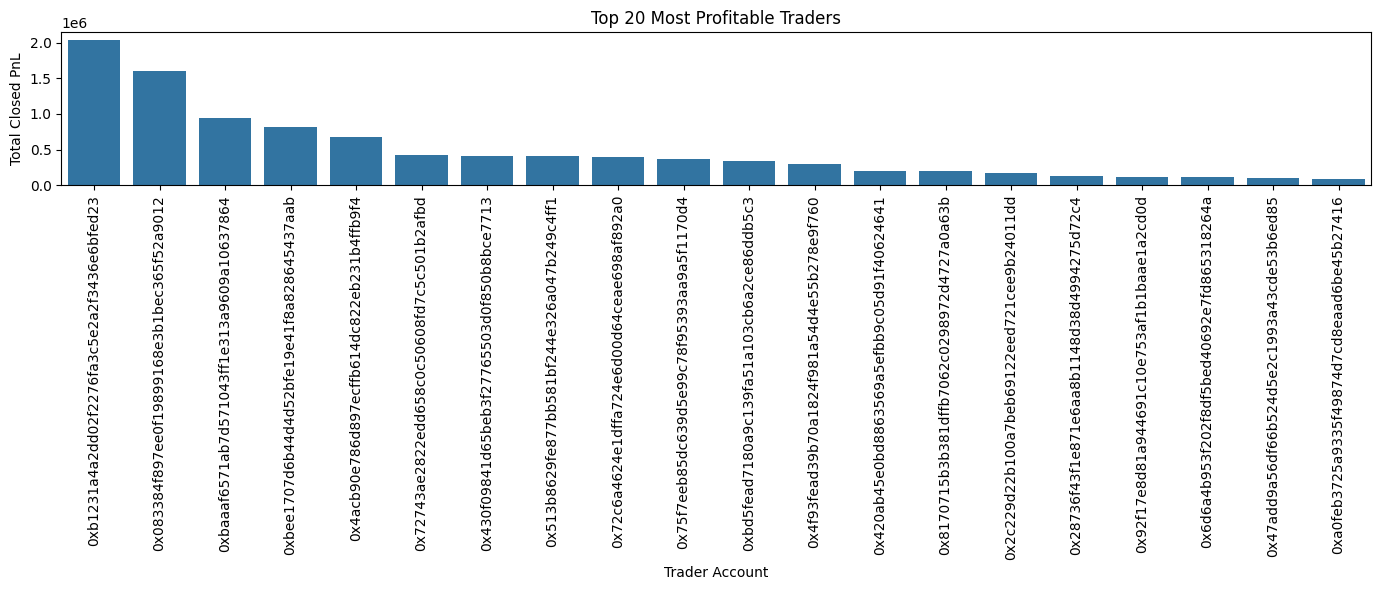

In [59]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=top_traders.index,
    y=top_traders.values
)

plt.title("Top 20 Most Profitable Traders")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [57]:
coin_count = df['Coin'].value_counts()

print(coin_count)

Coin
HYPE    62446
@107    27385
BTC     20135
ETH     10862
SOL      8523
        ...  
@42         1
@135        1
@18         1
@68         1
@86         1
Name: count, Length: 239, dtype: int64


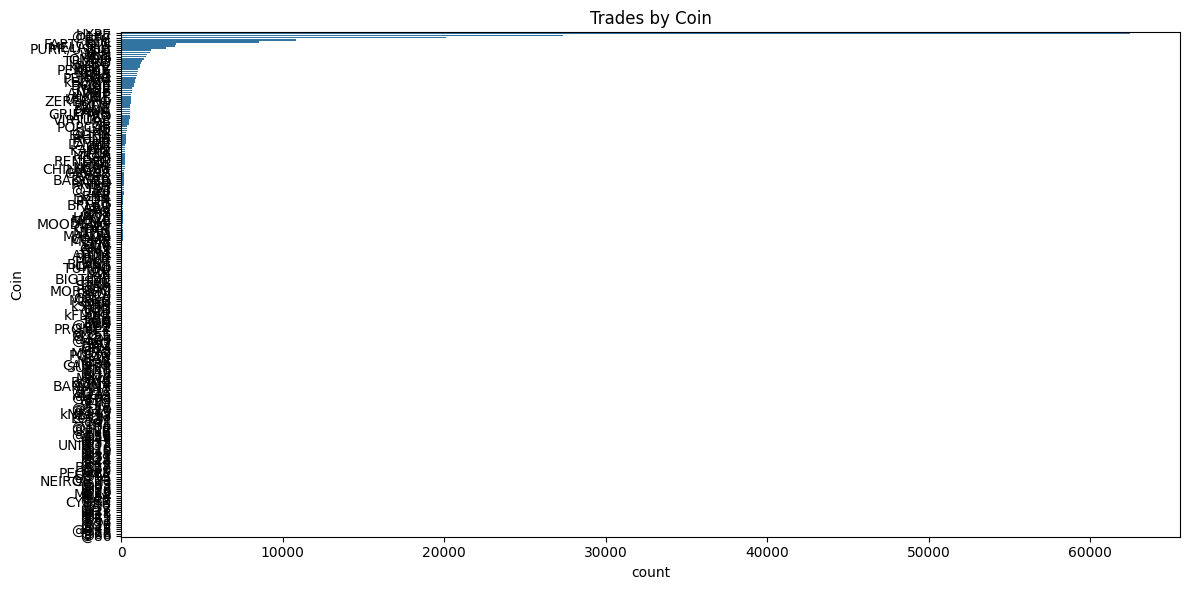

In [60]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Coin',
    order=coin_count.index
)

plt.title("Trades by Coin")

plt.tight_layout()
plt.show()

In [61]:
from scipy.stats import f_oneway

fear = df[df['classification']=='Fear']['Closed PnL']
greed = df[df['classification']=='Greed']['Closed PnL']
neutral = df[df['classification']=='Neutral']['Closed PnL']
extreme = df[df['classification']=='Extreme Greed']['Closed PnL']

F, p = f_oneway(fear, greed, neutral, extreme)

print("F-statistic:", F)
print("p-value:", p)

F-statistic: 21.33042041351781
p-value: 8.287959255248323e-14
